In [15]:
import asyncio
from codecs import StreamReader
from autogen_agentchat.agents import AssistantAgent, UserProxyAgent

from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination
from dotenv import load_dotenv
from autogen_agentchat.ui import Console
import os

load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')
model_client = OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)

python-dotenv could not parse statement starting at line 5
python-dotenv could not parse statement starting at line 6


In [16]:
assistant = AssistantAgent(
    name='Assistant',
    description='you are a great assistant',
    model_client=model_client,
    system_message='You are a really helpful assistant who help on the task given.'
)


In [17]:
user_proxy_agent = UserProxyAgent(
    name ='UserProxy',
    description='you are a user proxy agent',
    input_func=input
)


In [18]:
termination_condition = TextMentionTermination(text='APPROVE')

In [19]:

team = RoundRobinGroupChat(
    participants=[assistant, user_proxy_agent],
    termination_condition=termination_condition,
    max_turns=10
)

In [20]:

stream = team.run_stream(task = 'Write a great poem about india?')

In [21]:

async def main():
    await Console(stream)
    

In [22]:
await main()    

---------- TextMessage (user) ----------
Write a great poem about india?
---------- TextMessage (Assistant) ----------
In the land where the sacred rivers flow,  
Where the Himalayas wear their crowns of snow,  
India, a tapestry of ancient and new,  
A vibrant story told in every hue.  

From the bustling streets of timeless Delhi,  
To the serene ghats where waters gently eddy,  
Her history whispers through sandstone and sand,  
In each monument standing tall and grand.  

Fields of mustard in hues of gold,  
Stories of courage and legends bold,  
Spices wafting through the morning air,  
A fragrant symphony beyond compare.  

The Ganges' sacred waters gently glide,  
With secrets and prayers in its tide,  
From the Rajasthani deserts, vast and wide,  
To Kerala’s backwaters, where dreams reside.  

Her culture, a kaleidoscope of traditions,  
Dance and song that defy all divisions,  
From Bharatanatyam's elegant grace,  
To the soulful rhythms of a qawwali's embrace.  

Unity shine

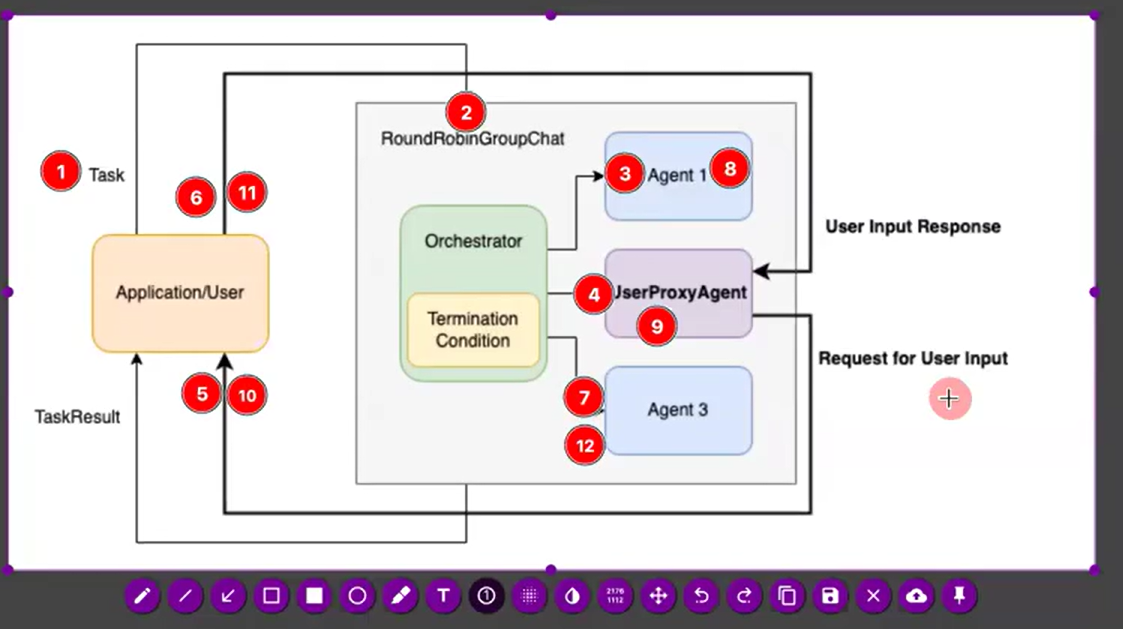